In [ ]:
from pathlib import Path

from astropy import table
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import pearsonr

from ugdatalab import GaiaData, StrictBPRP, LindegrenC2, StrictReddening
from ugdatalab.methods.bayesian.likelihoods import LinearGaussianLikelihood
from ugdatalab.methods.bayesian.mcmc import nuts_sample

from plotters import (
    plot_aitoff_reddening,
    plot_reddening_quality_diagnostics,
    plot_sfd_comparison,
    plot_sfd_regime_decomposition,
)

R_G = 2.0
MAX_SIGMA_E = 0.15

In [ ]:
def build_pc_arrays(data):
    """Return (x_centered, bp_rp, sigma_color, sigma_logp) for a period-color fit."""
    period = np.array(data["rrlyrae_representative_period"])
    period_err = np.array(data["rrlyrae_representative_period_error"])
    log_p = np.log10(period)
    bp_rp = np.array(data["bp_rp"])
    snr_bp = np.array(data["phot_bp_mean_flux_over_error"])
    snr_rp = np.array(data["phot_rp_mean_flux_over_error"])
    sigma_color = (2.5 / np.log(10)) * np.sqrt(1 / snr_bp**2 + 1 / snr_rp**2)
    sigma_logp = period_err / (period * np.log(10))
    return log_p - np.mean(log_p), bp_rp, sigma_color, sigma_logp


def compute_extinction(data, pc_result, mean_log_p, r_g=R_G):
    """Compute empirical E(BP-RP) and A_G for each star.

    Returns the table with added columns: E_bprp, A_G_calc, sigma_E.
    """
    out = data.copy()
    log_p = np.log10(np.array(data["rrlyrae_representative_period"]))
    bp_rp_obs = np.array(data["bp_rp"], dtype=float)

    slope, intercept, log10_sig = pc_result.theta
    bp_rp_int = slope * (log_p - mean_log_p) + intercept

    out["E_bprp"] = bp_rp_obs - bp_rp_int
    out["A_G_calc"] = r_g * (bp_rp_obs - bp_rp_int)

    snr_bp = np.array(data["phot_bp_mean_flux_over_error"], dtype=float)
    snr_rp = np.array(data["phot_rp_mean_flux_over_error"], dtype=float)
    sigma_color = (2.5 / np.log(10)) * np.sqrt(1 / snr_bp**2 + 1 / snr_rp**2)
    sigma_intrinsic = 10.0**log10_sig
    out["sigma_E"] = np.sqrt(sigma_color**2 + sigma_intrinsic**2)

    return out


def _wrap(data):
    """Wrap a table for pipeline classes."""
    w = GaiaData.__new__(GaiaData)
    w.data = data
    w.query = ""
    w.include_lightcurve = False
    w.lightcurves = None
    return w

In [3]:
data = np.load(Path("rrlyrae_calibration_sample.npz"), allow_pickle=True)
rrlyrae = table.Table({k: data[k] for k in data.files})

rrab_cal = rrlyrae[rrlyrae["best_classification"] == "RRab"]
rrc_cal = rrlyrae[rrlyrae["best_classification"] == "RRc"]

rrab_pc_result = nuts_sample(LinearGaussianLikelihood(*build_pc_arrays(rrab_cal)))
rrc_pc_result = nuts_sample(LinearGaussianLikelihood(*build_pc_arrays(rrc_cal)))

rrab_mean_log_p = float(np.mean(np.log10(rrab_cal["rrlyrae_representative_period"])))
rrc_mean_log_p = float(np.mean(np.log10(rrc_cal["rrlyrae_representative_period"])))

print(f"RRab PC fit: slope={rrab_pc_result.theta[0]:.4f}, "
      f"intercept={rrab_pc_result.theta[1]:.4f}")
print(f"RRc  PC fit: slope={rrc_pc_result.theta[0]:.4f}, "
      f"intercept={rrc_pc_result.theta[1]:.4f}")

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [a, b, log10_sig]


Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 1 seconds.


Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [a, b, log10_sig]


Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 2 seconds.


RRab PC fit: slope=0.2484, intercept=0.6487
RRc  PC fit: slope=0.4794, intercept=0.4450


In [ ]:
FULL_CATALOG_PATH = Path("rrlyrae_full_catalog.npz")

if FULL_CATALOG_PATH.exists():
    _npz = np.load(FULL_CATALOG_PATH, allow_pickle=True)
    full_data = table.Table({k: _npz[k] for k in _npz.files})
else:
    query = """
    SELECT *
    FROM gaiadr3.vari_rrlyrae AS vr
    JOIN gaiadr3.gaia_source AS gs
        ON vr.source_id = gs.source_id
    """
    full_data = GaiaData(query).data
    np.savez_compressed(
        FULL_CATALOG_PATH,
        **{col: np.array(full_data[col]) for col in full_data.colnames},
    )

print(f"Full catalog: {len(full_data):,} stars")

In [ ]:
# Photometric quality pipeline
photometric = LindegrenC2(StrictBPRP(_wrap(full_data)))

# Compute extinction per class
rrab = photometric.data[photometric.data["best_classification"] == "RRab"]
rrc = photometric.data[photometric.data["best_classification"] == "RRc"]
rrab_ext = compute_extinction(rrab, rrab_pc_result, rrab_mean_log_p)
rrc_ext = compute_extinction(rrc, rrc_pc_result, rrc_mean_log_p)
rrlyrae_extinction = table.vstack([rrab_ext, rrc_ext])

# Reddening quality pipeline
rrlyrae_clean = StrictReddening(_wrap(rrlyrae_extinction)).data

print(f"After StrictBPRP + LindegrenC2: {len(photometric.data):,}")
print(f"After extinction computation:   {len(rrlyrae_extinction):,}")
print(f"After StrictReddening:          {len(rrlyrae_clean):,}")

In [ ]:
e_all = np.array(rrlyrae_extinction["E_bprp"], dtype=float)
finite = np.isfinite(e_all)
vmin = float(min(0.0, np.nanpercentile(e_all[finite], 0.5)))
vmax = float(np.nanpercentile(e_all[finite], 99.5))

fig, ax = plot_aitoff_reddening(
    np.array(rrlyrae_extinction["l"], dtype=float)[finite],
    np.array(rrlyrae_extinction["b"], dtype=float)[finite],
    e_all[finite],
    vmin=vmin, vmax=vmax,
)
ax.set_title(f"Uncut reddening map ($N$ = {finite.sum():,})", pad=20)
plt.show()

In [ ]:
axes = plot_reddening_quality_diagnostics(
    np.array(rrlyrae_extinction["bp_rp"], dtype=float)[finite],
    np.array(rrlyrae_extinction["phot_bp_rp_excess_factor"], dtype=float)[finite],
    np.array(rrlyrae_extinction["sigma_E"], dtype=float)[finite],
    max_sigma_e=MAX_SIGMA_E,
)
plt.show()

In [ ]:
fig, ax = plot_aitoff_reddening(
    np.array(rrlyrae_clean["l"], dtype=float),
    np.array(rrlyrae_clean["b"], dtype=float),
    np.array(rrlyrae_clean["E_bprp"], dtype=float),
    vmin=vmin, vmax=vmax,
)
ax.set_title(f"Quality-cut reddening map ($N$ = {len(rrlyrae_clean):,})", pad=20)
plt.show()

In [ ]:
from dustmaps.config import config as dustmaps_config
import dustmaps.sfd
from dustmaps.sfd import SFDQuery
from astropy.coordinates import SkyCoord
import astropy.units as u

DUSTMAPS_DATA_DIR = Path(".dustmaps-data")
DUSTMAPS_DATA_DIR.mkdir(parents=True, exist_ok=True)
dustmaps_config["data_dir"] = str(DUSTMAPS_DATA_DIR.resolve())

try:
    sfd = SFDQuery()
except FileNotFoundError:
    dustmaps.sfd.fetch()
    sfd = SFDQuery()

coords = SkyCoord(
    l=np.array(rrlyrae_clean["l"], dtype=float) * u.deg,
    b=np.array(rrlyrae_clean["b"], dtype=float) * u.deg,
    frame="galactic",
)
sfd_ebv = np.array(sfd(coords), dtype=float)
empirical = np.array(rrlyrae_clean["E_bprp"], dtype=float)

print(f"Cleaned sample with SFD: {len(rrlyrae_clean):,} stars")
print(f"Median SFD E(B-V):       {np.nanmedian(sfd_ebv):.4f} mag")
print(f"Median empirical E:      {np.nanmedian(empirical):.4f} mag")

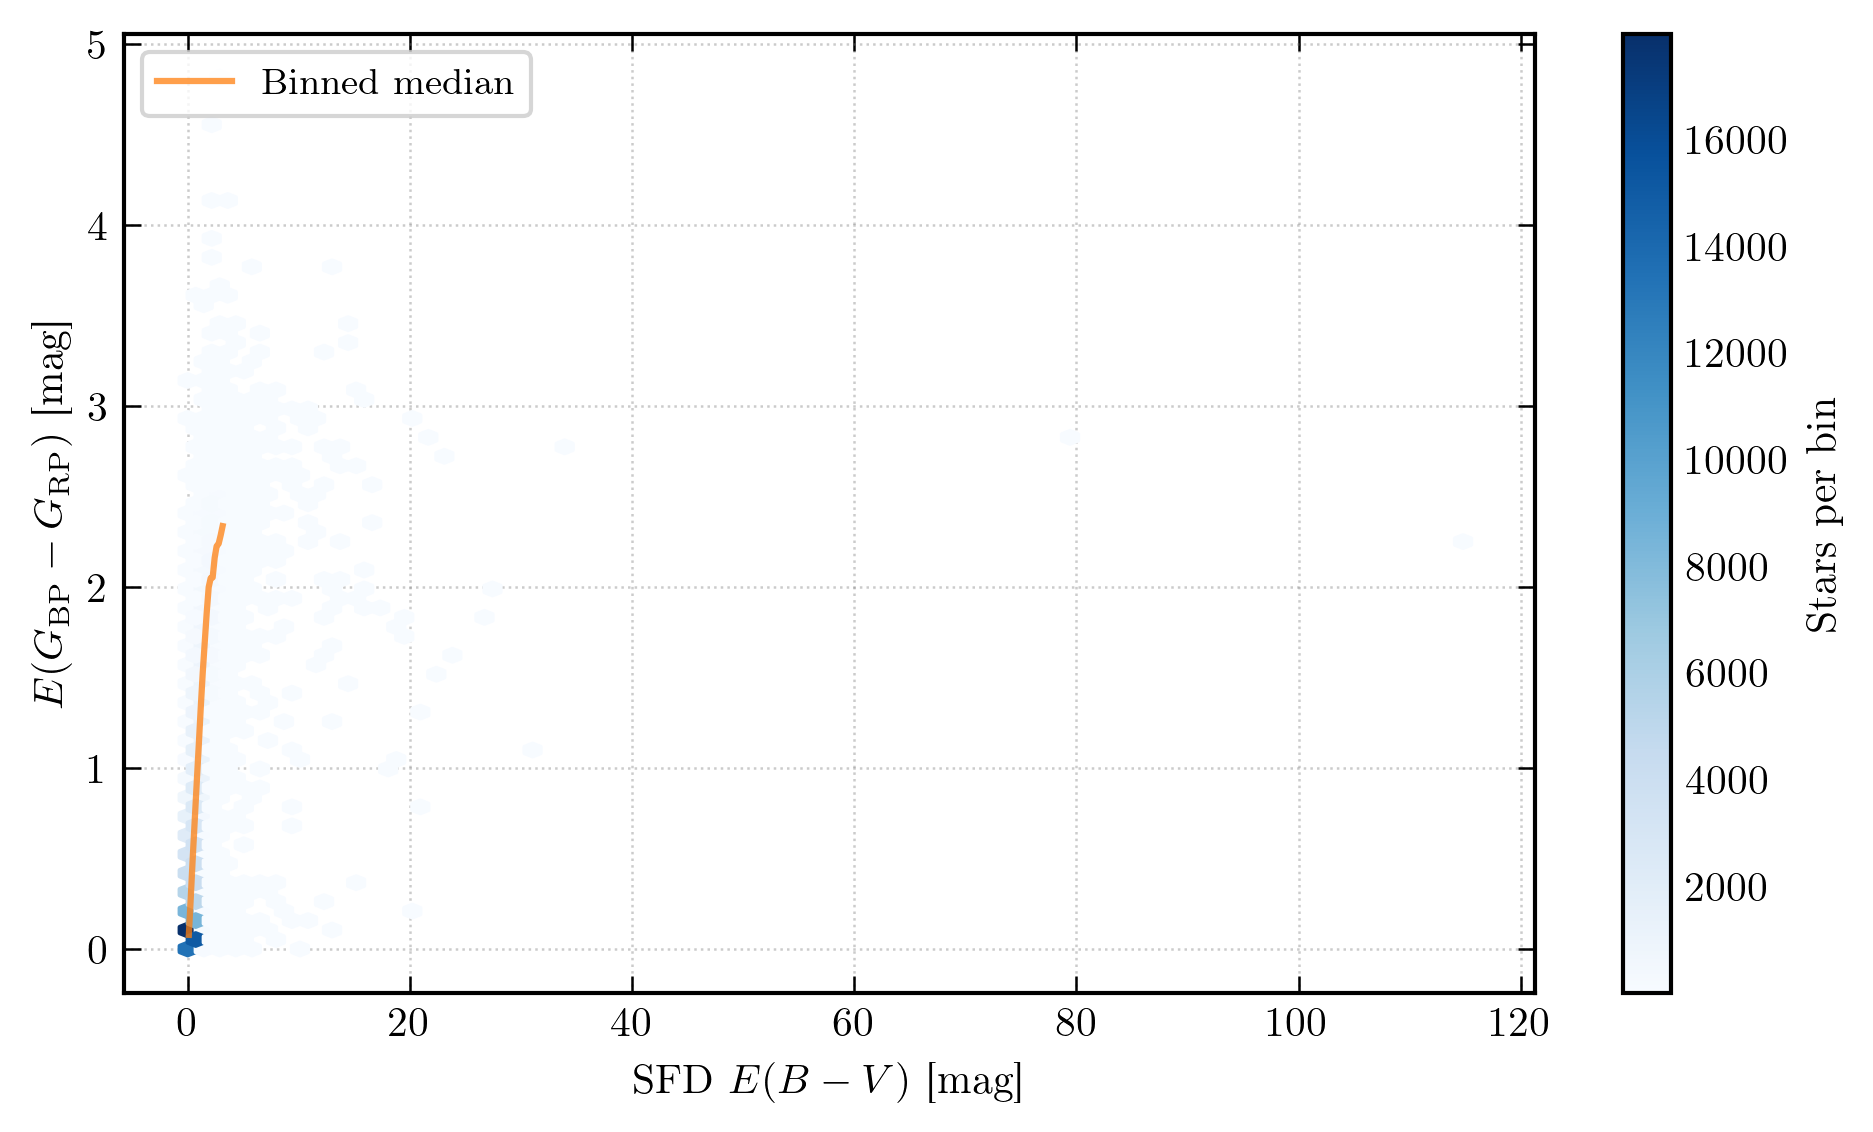

In [10]:
fig, ax = plot_sfd_comparison(sfd_ebv, empirical)
plt.show()

Similar-scale: 128,147 stars, slope=1.111, R²=0.877
Large-SFD:     77 stars


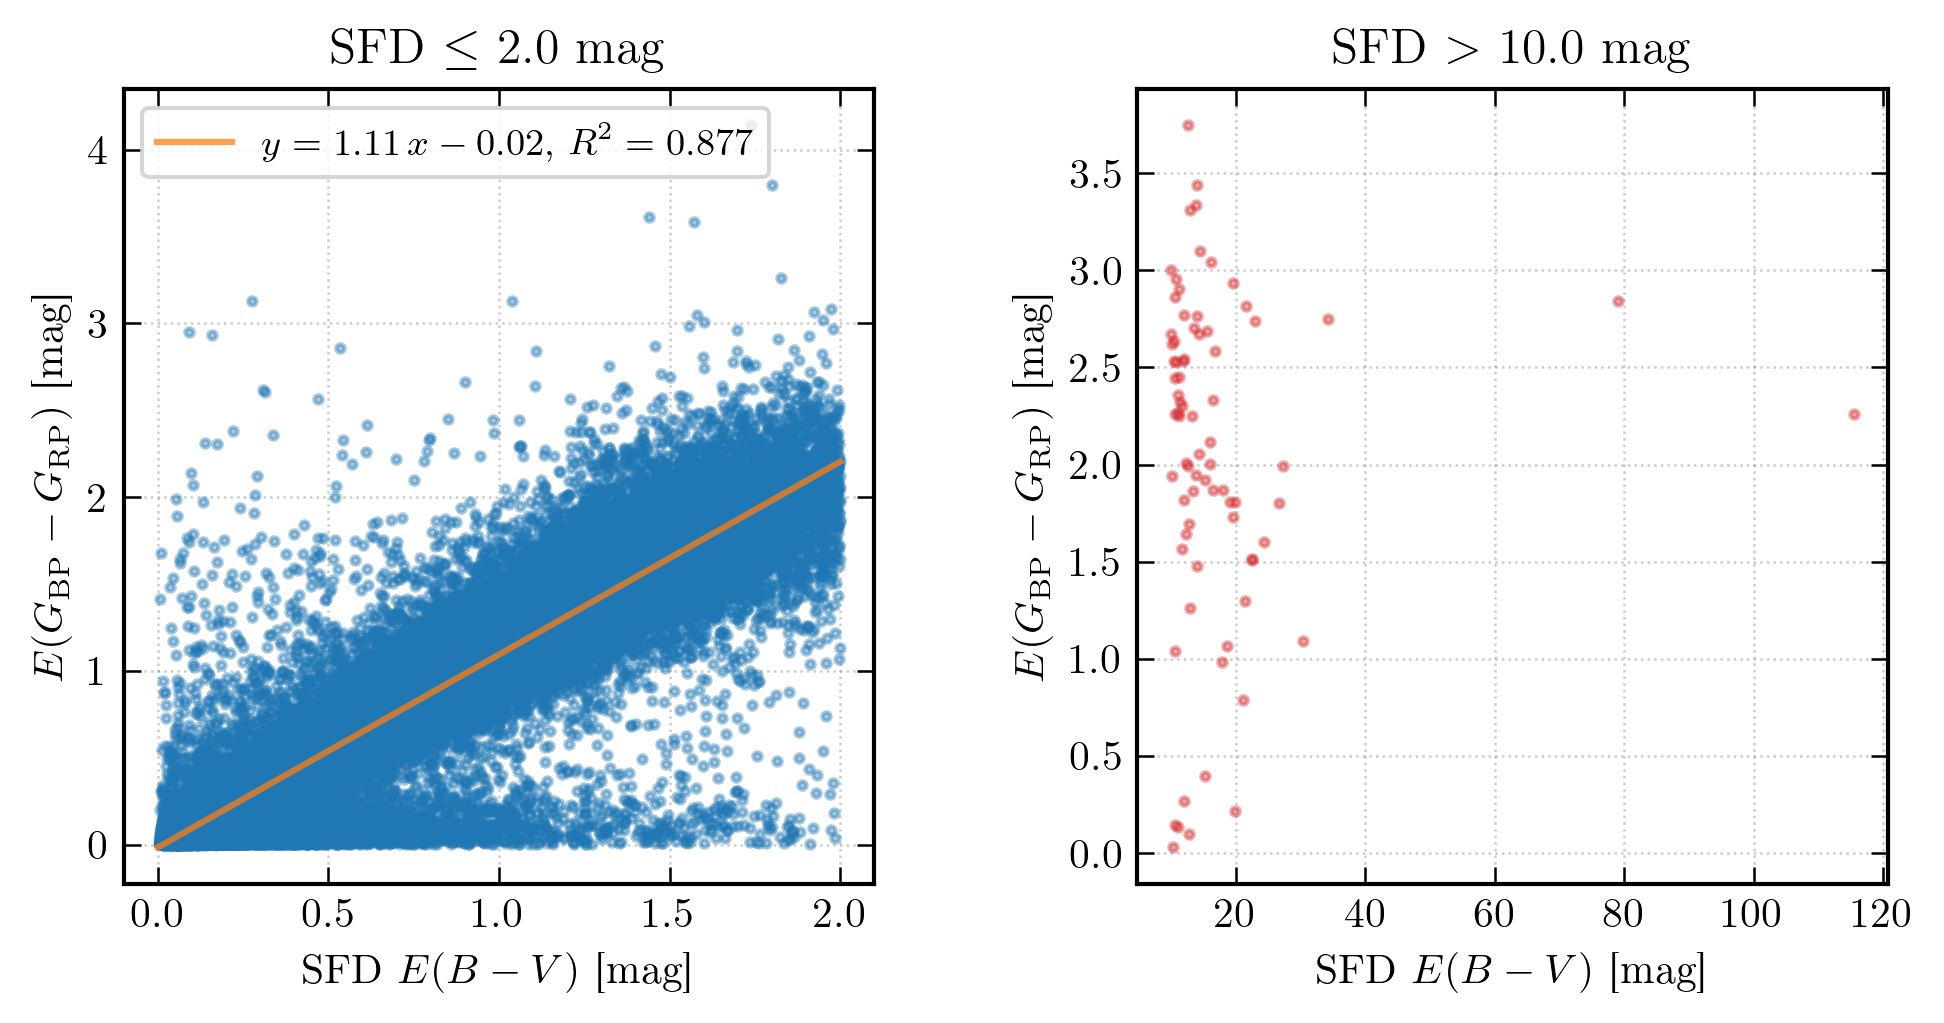

In [11]:
SIMILAR_SCALE_MAX = 2.0
LARGE_SFD_MIN = 10.0

finite_mask = np.isfinite(sfd_ebv) & np.isfinite(empirical)
similar_mask = finite_mask & (sfd_ebv <= SIMILAR_SCALE_MAX)
large_mask = finite_mask & (sfd_ebv > LARGE_SFD_MIN)

x_sim = sfd_ebv[similar_mask]
y_sim = empirical[similar_mask]
slope, intercept = np.polyfit(x_sim, y_sim, 1)
r_sim, _ = pearsonr(x_sim, y_sim)

print(f"Similar-scale: {similar_mask.sum():,} stars, slope={slope:.3f}, R²={r_sim**2:.3f}")
print(f"Large-SFD:     {large_mask.sum():,} stars")

axes = plot_sfd_regime_decomposition(
    sfd_ebv, empirical, similar_mask, large_mask,
    slope, intercept, r_sim**2,
    similar_scale_max=SIMILAR_SCALE_MAX, large_sfd_min=LARGE_SFD_MIN,
)
plt.show()